In [1]:
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')
import torch

from dig.sslgraph.utils import Encoder
from dig.sslgraph.evaluation import GraphUnsupervised
from dig.sslgraph.evaluation import Finetune
from dig.threedgraph.dataset import MoleculeNet
from dig.threedgraph.method import SchNet
from dig.sslgraph.method import GraphCL

import matplotlib.pyplot as plt

from rdkit import RDLogger 
RDLogger.DisableLog('rdApp.*')

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import pandas as pd
from rdkit import Chem
import rdkit.Chem.AllChem as AllChem

import argparse

paser = argparse.ArgumentParser()
args = paser.parse_args("")

C:\Users\aiden\AppData\Local\Temp\ipykernel_35272\3539213752.py:18: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [2]:
### Finetune or rand init
args.finetune = True
args.seed = 2222

# File Path
#args.model_path = './models/encoder-schnet_pretrain-esol_batch-400_proj-spherenet_cutoff-5.0_layers-2_filter-128_gau-50_z_dim-64_lr-0.001\
#_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0/enc_best_epoch-13_loss-8.024.pkl'

args.model_path = './models/encoder-schnet_pretrain-esol_batch-400_proj-spherenet_cutoff-5.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0\enc_best_epoch-82_loss-9.112.pkl'

# Device
args.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Dataset
args.dataset = 'esol'

args.batch_size = 32

# Model
args.encoder = 'schnet'
args.cutoff = 5.0  # [5.0, 10.0]
args.num_layers = 2 # [2, 4]
args.num_filters = 128
args.num_gaussians = 50
# 반드시 체크포인트(프리트레인)의 z_dim과 동일해야 load_state_dict가 맞음 — 경로의 z_dim-32 참고
args.z_dim = 32

args.edge_weight = False

# Learning
args.n_times = 1
args.n_folds = 3
args.f_epoch = 100
args.f_lr = 1e-3
args.aug_1, args.aug_2 = 'MMFFrandom', 'MMFFrandom'
args.aug_ratio = 0.2
args.tau = 0.2
args.proj = 'schnet'

# Regularization
args.dropout_rate = 0.0
#aug

args.f_optim = 'ExponentialLR' #['StepLR', ExponentialLR, 'Cosine']
args.f_weight_decay = 5e-5

#'StepLR'
args.f_lr_decay_step_size = 20  # 15 epoch 마다 lr * p_lr_decay_factor
args.f_lr_decay_factor = 0.5

# ExponentialLR 
args.expo_gamma = 0.95

# Cosine
args.T_0 = 100        # 최초 주기값
args.T_mult = 1      # 최초 주기값에 비해 얼만큼 주기를 늘려갈 것인지
args.eta_max = 0.05  # lr 최대값
args.T_up = 10        # Warm up 시 필요한 epoch 수(일반적으로 짧은 수)
args.gamma = 0.5     # 주기가 반복될수록 곱해지는 scale 값

args.batch_lst = [32]
args.cutoff_lst = [5.0]
args.num_layers_lst = [2]
args.num_filters_lst = [128]
args.num_gaussians_lst = [50]
args.z_dim_lst = [32]
args.dropout_rate_lst = [0.1]
args.target_lst = ['y']
args.f_lr_lst = [2e-3]
args.f_weight_decay_lst = [1e-3]

evaluator = Finetune(args=args, log_interval=10)
auc_m_lst, auc_sd_lst, paras, total, args = evaluator.grid_search(args)

c:\DGCL\3DGCL\examples\sslgraph\../..\dig\sslgraph\evaluation\finetune.py:256: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  self.dataset.data.y = self.dataset.data[self.target]


904 112 112


Finetune: epoch 4:   3%|▎         | 3/100 [00:26<14:02,  8.69s/it, FOLD=1.0, best_test_loss=1.256, best_val_loss=1.356, test_rmse=1.256, train_rmse=1.078, val_rmse=1.356]


KeyboardInterrupt: 

Plots for grid index=0 (lowest mean test RMSE among grid)
Pooled RMSE over folds ≈ 0.8959 | grid avg reported RMSE ≈ 0.8876


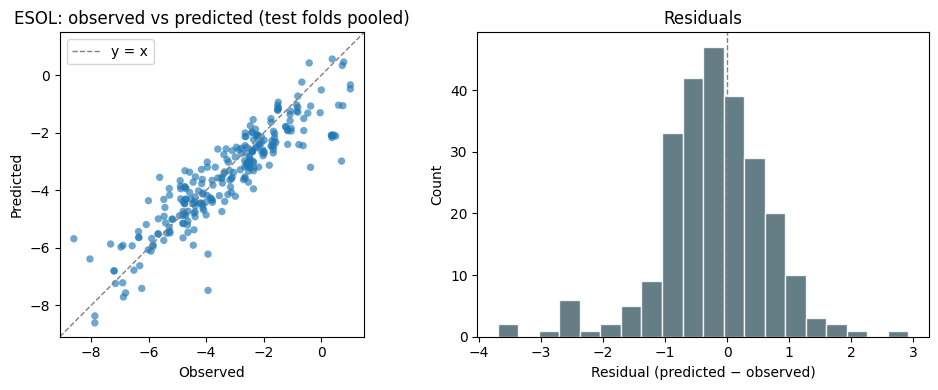

In [3]:
# 위 셀에서 `grid_search`를 실행한 직후에만 동작합니다.
import numpy as np
import matplotlib.pyplot as plt

# total: [(하이퍼파라 설정 튜플, 평균 test RMSE), ...]
losses_grid = np.array([loss for (_, loss) in total])
best_i = int(np.argmin(losses_grid))

def _flatten_folds(lst):
    """evaluate() 반환 리스트는 폴딩마다 하나의 ndarray — 전부 붙입니다."""
    parts = lst[best_i]
    ys = []
    for a in parts:
        ys.append(np.asarray(a, dtype=float).reshape(-1))
    return np.concatenate(ys, axis=0)

y_obs = _flatten_folds(args.list_test_trues)
y_hat = _flatten_folds(args.list_test_preds)
rmse = float(np.sqrt(np.mean((y_hat - y_obs) ** 2)))
res = y_hat - y_obs

print(f"Plots for grid index={best_i} (lowest mean test RMSE among grid)")
print(f"Pooled RMSE over folds ≈ {rmse:.4f} | grid avg reported RMSE ≈ {losses_grid[best_i]:.4f}")

lim = np.min([y_obs.min(), y_hat.min()]), np.max([y_obs.max(), y_hat.max()])
pad = 0.05 * (lim[1] - lim[0])
lims = lim[0] - pad, lim[1] + pad

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_obs, y_hat, alpha=0.65, edgecolors="none", s=28)
axes[0].plot(lims, lims, linestyle="--", color="gray", lw=1, label="y = x")
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("Observed")
axes[0].set_ylabel("Predicted")
axes[0].set_title("ESOL: observed vs predicted (test folds pooled)")
axes[0].legend(loc="upper left")

axes[1].hist(res, bins=20, color="#4a6670", alpha=0.85, edgecolor="white")
axes[1].axvline(0, color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("Residual (predicted − observed)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals")

plt.tight_layout()
plt.show()


In [ ]:
# grid_search 결과를 파일로 저장 (분자별 실제값/예측값/오차)
import numpy as np
import pandas as pd
from pathlib import Path

losses_grid = np.array([loss for (_, loss) in total])
best_i = int(np.argmin(losses_grid))

def _flatten_any(lst):
    parts = lst[best_i]
    out = []
    for a in parts:
        out.append(np.asarray(a).reshape(-1))
    return np.concatenate(out, axis=0)

y_true = _flatten_any(args.list_test_trues).astype(float)
y_pred = _flatten_any(args.list_test_preds).astype(float)
smiles = _flatten_any(args.list_test_smiles)

n = min(len(y_true), len(y_pred), len(smiles))
df = pd.DataFrame(
    {
        "smiles": smiles[:n],
        "y_true": y_true[:n],
        "y_pred": y_pred[:n],
    }
)
df["abs_error"] = (df["y_pred"] - df["y_true"]).abs()

out_dir = Path("./results") / args.dataset / args.encoder
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / "predictions_best_grid.csv"
df.to_csv(out_csv, index=False)

print(f"saved: {out_csv.resolve()}")
print(df.head(10))

saved: C:\DGCL\3DGCL\examples\sslgraph\results\esol\schnet\predictions_best_grid.csv
                                              smiles  y_true    y_pred  \
0             Oc1ccc(Cl)cc1C(=O)Nc2ccc(cc2Cl)N(=O)=O   -4.70 -4.310008   
1                        c1c(NC(=O)c2ccccc2(I))cccc1   -4.21 -4.440050   
2                          c1ccccc1NC(=O)c2c(O)cccc2   -3.59 -2.561519   
3        Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O   -3.79 -3.650096   
4         CCOc1ccc(cc1)C(C)(C)COCc3cccc(Oc2ccccc2)c3   -8.60 -5.680485   
5  ClC1(C2(Cl)C3(Cl)C4(Cl)C5(Cl)C1(Cl)C3(Cl)Cl)C5...   -6.80 -7.564013   
6                CC34CCC1C(CC=C2CC(O)CCC12C)C3CCC4=O   -4.12 -4.129590   
7      CC2Nc1cc(Cl)c(cc1C(=O)N2c3ccccc3C)S(N)(=O)=O    -3.78 -4.336694   
8                       Oc1cc(Cl)ccc1Oc2ccc(Cl)cc2Cl   -4.46 -4.456927   
9                 COc2ccc(Oc1ccc(NC(=O)N(C)C)cc1)cc2   -4.16 -3.268610   

   abs_error  
0   0.389992  
1   0.230050  
2   1.028481  
3   0.139904  
4   2.919516  
5   0.7640